# Strategy 6: Relevance-Filtered Direction — Only Trade Real Speeches

Tests whether filtering out low-relevance / low-impact speeches improves
the baseline `trailing_5_avg` level signal. Five filter variants:

1. **Baseline** — no filter (trailing\_5\_avg ±10)
2. **Impact** — ForexFactory impact = high or medium
3. **Relevance** — JPM relevance\_scored\_pct ≥ 40
4. **Combined** — impact high/medium AND relevance ≥ 40
5. **Strict** — impact = high AND relevance ≥ 50 AND permanent voter

In [1]:
%load_ext autoreload
%autoreload 2
import sys; sys.path.insert(0, r"C:\Users\chris\clee\ARBS")
import datetime, pytz, re, numpy as np, pandas as pd
from collections import defaultdict
import matplotlib.pyplot as plt, matplotlib.pylab as pylab, seaborn as sns
plt.style.use("ggplot")
pylab.rcParams.update({"legend.fontsize": "large", "figure.figsize": (14, 8),
    "axes.labelsize": "x-large", "axes.titlesize": "x-large",
    "xtick.labelsize": "large", "ytick.labelsize": "large"})
import QuantLib as ql

NYC_tz = pytz.timezone("America/New_York")
ENTRY_OFFSET = datetime.timedelta(minutes=45)
EXIT_OFFSET  = datetime.timedelta(minutes=180)
CURVE = "USD-SOFR-1D-Q12STIRT"
TENOR = "IMM_3xIMM_4"
BASE_BPV = 100_000
MDP_SOURCE = "BARCHART_STIRF-RL"
BT_START = "2021-01-01"
BT_END   = "2026-06-30"
HAWK_THRESH = 10
DOVE_THRESH = -10
EARLIEST_SPEECH = datetime.time(7, 0)
LATEST_SPEECH   = datetime.time(17, 0)
BLACKOUT_BD = 1

PERMANENT_VOTERS = {
    "Powell", "Williams", "Bowman", "Cook", "Jefferson",
    "Kugler", "Waller", "Barr", "Brainard",
}

print("Config loaded.")

Config loaded.


## 1. Load Data

In [2]:
from RVUtils.forex_factory_calendar import ForexFactoryCalendarFetcher, ForexFactoryTheme
fetcher = ForexFactoryCalendarFetcher()
fed_speak_df = fetcher.fetch_range(BT_START, BT_END,
    themes=[ForexFactoryTheme.FED_SPEAKERS], show_tqdm=True, bulk_chunk_weeks=52)
print(f"ForexFactory events: {len(fed_speak_df)}")

jpm = pd.read_csv(r"C:\Users\chris\clee\project-oasis\private\jpm_research\fed_speak_nlp\fed_hawk_dove_scores.csv")
jpm["date"] = pd.to_datetime(jpm["date"]).dt.date
jpm = jpm.sort_values(["speaker", "date"]).reset_index(drop=True)
KNOWN = sorted(jpm["speaker"].unique())
print(f"JPM speakers: {len(KNOWN)}")

# Show impact distribution
print("\nImpact distribution:")
print(fed_speak_df["Impact"].value_counts().to_string())

Fetching missing Forex Factory weeks: 0it [00:00, ?it/s]

Fetching missing Forex Factory weeks: 0it [00:00, ?it/s]

ForexFactory events: 1483
JPM speakers: 23

Impact distribution:
Impact
low       1153
medium     232
high        98


## 2. Engine

In [3]:
from BT.data_handler import TimeGrid
from BT.query_actions import AddQueryAction, UnwindPositionsAction
from BT.query_engine import QueryDrivenBacktest
from BT.query_strategy import QueryStrategy
from BT.triggers import Trigger, FlowSignalTriggerRequirements
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP
from Query.IRSwaps.IRSwapQuery import IRSwapQuery
from Query.IRSwaps.IRSwapValue import IRSwapValue

curve_mdp = IRSwapsMDP(source=MDP_SOURCE)

FOMC_DATES = [
    datetime.date(2020,1,29),datetime.date(2020,3,15),datetime.date(2020,4,29),
    datetime.date(2020,6,10),datetime.date(2020,7,29),datetime.date(2020,9,16),
    datetime.date(2020,11,5),datetime.date(2020,12,16),
    datetime.date(2021,1,27),datetime.date(2021,3,17),datetime.date(2021,4,28),
    datetime.date(2021,6,16),datetime.date(2021,7,28),datetime.date(2021,9,22),
    datetime.date(2021,11,3),datetime.date(2021,12,15),
    datetime.date(2022,1,26),datetime.date(2022,3,16),datetime.date(2022,5,4),
    datetime.date(2022,6,15),datetime.date(2022,7,27),datetime.date(2022,9,21),
    datetime.date(2022,11,2),datetime.date(2022,12,14),
    datetime.date(2023,2,1),datetime.date(2023,3,22),datetime.date(2023,5,3),
    datetime.date(2023,6,14),datetime.date(2023,7,26),datetime.date(2023,9,20),
    datetime.date(2023,11,1),datetime.date(2023,12,13),
    datetime.date(2024,1,31),datetime.date(2024,3,20),datetime.date(2024,5,1),
    datetime.date(2024,6,12),datetime.date(2024,7,31),datetime.date(2024,9,18),
    datetime.date(2024,11,7),datetime.date(2024,12,18),
    datetime.date(2025,1,29),datetime.date(2025,3,19),datetime.date(2025,5,7),
    datetime.date(2025,6,18),datetime.date(2025,7,30),datetime.date(2025,9,17),
    datetime.date(2025,10,29),datetime.date(2025,12,10),
    datetime.date(2026,1,28),datetime.date(2026,3,18),datetime.date(2026,4,29),
    datetime.date(2026,6,17),
]
ql_cal = ql.UnitedStates(ql.UnitedStates.GovernmentBond)

def extract_speaker(title):
    cleaned = re.sub(r"\b(Speaks?|Testifies|Testimony)\b", "", title).strip()
    return cleaned.split()[-1] if cleaned.split() else ""

def is_in_blackout(event_date):
    for f in FOMC_DATES:
        s = ql.Date(f.day, f.month, f.year)
        lo = ql_cal.advance(s, ql.Period(-BLACKOUT_BD, ql.Days), ql.Preceding)
        hi = ql_cal.advance(s, ql.Period(BLACKOUT_BD, ql.Days), ql.Following)
        if (datetime.date(lo.year(), lo.month(), lo.dayOfMonth())
                <= event_date <= datetime.date(hi.year(), hi.month(), hi.dayOfMonth())):
            return True
    return False

def cap_exit(exit_ts, entry_ts):
    eq = ql.Date(exit_ts.day, exit_ts.month, exit_ts.year)
    if exit_ts.hour >= 17:
        return exit_ts.replace(hour=16, minute=59, second=0, microsecond=0)
    if not ql_cal.isBusinessDay(eq):
        return entry_ts.replace(hour=16, minute=59, second=0, microsecond=0)
    return exit_ts

_caches = {}
for col in ["trailing_5_avg", "relevance_scored_pct"]:
    cache = {}
    for speaker, grp in jpm.groupby("speaker"):
        g = grp.sort_values("date")
        cache[speaker] = (g["date"].values, g[col].values)
    _caches[col] = cache

def _lookup(col, speaker, as_of):
    if speaker not in _caches[col]: return np.nan
    dates, vals = _caches[col][speaker]
    mask = dates < np.datetime64(as_of)
    return float(vals[mask][-1]) if mask.any() else np.nan

print("Engine ready.")

Engine ready.


## 3. Build Events — All Filter Variants

In [4]:
def build_events(impact_filter=None, min_relevance=None, voter_only=False, label=""):
    events = []
    excluded = defaultdict(int)
    for _, row in fed_speak_df.iterrows():
        speaker = extract_speaker(row["Title"])
        if speaker not in KNOWN:
            excluded["unknown"] += 1
            continue
        ts = row["TimestampNYC"]
        if pd.isna(ts): continue
        if ts.tzinfo is None: ts = NYC_tz.localize(ts)
        if ts.time() < EARLIEST_SPEECH or ts.time() > LATEST_SPEECH: continue
        if is_in_blackout(ts.date()): continue
        if "press conference" in row["Title"].lower(): continue

        # Impact filter
        if impact_filter is not None:
            if row.get("Impact", "low") not in impact_filter:
                excluded["impact_filtered"] += 1
                continue

        # Voter filter
        if voter_only and speaker not in PERMANENT_VOTERS:
            excluded["non_voter"] += 1
            continue

        t5 = _lookup("trailing_5_avg", speaker, ts.date())
        if pd.isna(t5): continue

        # Relevance filter (from JPM scores)
        if min_relevance is not None:
            rel = _lookup("relevance_scored_pct", speaker, ts.date())
            if pd.isna(rel) or rel < min_relevance:
                excluded["low_relevance"] += 1
                continue

        if t5 >= HAWK_THRESH:
            d = 1
        elif t5 <= DOVE_THRESH:
            d = -1
        else:
            excluded["neutral"] += 1
            continue

        entry = ts - ENTRY_OFFSET
        eq = ql.Date(entry.day, entry.month, entry.year)
        if not ql_cal.isBusinessDay(eq): continue
        exit_ = cap_exit(ts + EXIT_OFFSET, entry)

        events.append({
            "speaker": speaker, "speech_ts": ts,
            "entry_ts": entry, "exit_ts": exit_,
            "direction": d,
            "direction_label": "hawk" if d == 1 else "dove",
            "bpv": -d * BASE_BPV,
            "tag": f"e_{len(events)}",
        })

    events.sort(key=lambda e: e["entry_ts"])
    filt, last = [], None
    for ev in events:
        if last is not None and ev["entry_ts"] < last: continue
        filt.append(ev)
        last = ev["exit_ts"]
    return filt

VARIANTS = {
    "1. Baseline": dict(),
    "2. Impact (H/M)": dict(impact_filter={"high", "medium"}),
    "3. Relevance>=40": dict(min_relevance=40),
    "4. Combined": dict(impact_filter={"high", "medium"}, min_relevance=40),
    "5. Strict": dict(impact_filter={"high"}, min_relevance=50, voter_only=True),
}

all_events = {}
for name, kwargs in VARIANTS.items():
    evts = build_events(**kwargs, label=name)
    all_events[name] = evts
    n_h = sum(1 for e in evts if e["direction"] == 1)
    n_d = sum(1 for e in evts if e["direction"] == -1)
    print(f"{name:25s}: {len(evts):4d} trades (hawk={n_h}, dove={n_d})")

1. Baseline              :  461 trades (hawk=386, dove=75)


2. Impact (H/M)          :  124 trades (hawk=109, dove=15)


3. Relevance>=40         :  351 trades (hawk=323, dove=28)


4. Combined              :  100 trades (hawk=96, dove=4)


5. Strict                :   40 trades (hawk=40, dove=0)


## 4. Run Backtests

In [5]:
def run_bt(events, label):
    if len(events) < 3:
        print(f"  {label}: too few events ({len(events)}), skipping")
        return None
    exit_set = set(e["exit_ts"] for e in events)
    ts_all = sorted(set(e["entry_ts"] for e in events) | exit_set)
    exit_trig = Trigger(
        trigger_requirements=FlowSignalTriggerRequirements(
            signal_fn=lambda s, bt: s in exit_set),
        actions=[UnwindPositionsAction(match_all=True, fee=0.0)])
    entry_trigs = []
    for ev in events:
        _ts = ev["entry_ts"]
        _q = IRSwapQuery(curve=CURVE, tenor=TENOR, value=IRSwapValue.NPV,
            structure_kwargs={"bpv": ev["bpv"]}, tags=(ev["tag"],),
            meta={"speaker": ev["speaker"], "direction": ev["direction"]})
        def _mk(t):
            def fn(s, bt): return s == t and len(bt.portfolio.positions) == 0
            return fn
        entry_trigs.append(Trigger(
            trigger_requirements=FlowSignalTriggerRequirements(signal_fn=_mk(_ts)),
            actions=[AddQueryAction(query=_q)]))
    strat = QueryStrategy(name=label, triggers=[exit_trig] + entry_trigs)
    bt = QueryDrivenBacktest(time_grid=TimeGrid(ts_all), mdp=curve_mdp, strategy=strat,
                             show_progress=True, progress_desc=f"  {label[:20]}")
    bt.run()
    return bt

def extract_closed(bt):
    cl = pd.DataFrame(bt.portfolio.closed_positions_log)
    cl["speaker"] = cl["source_query"].apply(lambda q: q.meta["speaker"])
    cl["direction"] = cl["source_query"].apply(lambda q: q.meta["direction"])
    cl["direction_label"] = cl["direction"].apply(lambda d: "hawk" if d == 1 else "dove")
    cl["opened_at"] = pd.to_datetime(cl["opened_at"])
    cl["year"] = cl["opened_at"].dt.year
    cl["pnl_bps"] = cl["realized_pnl"] / BASE_BPV
    cl["profitable"] = cl["pnl_bps"] > 0
    cl["cum_bps"] = cl["pnl_bps"].cumsum()
    return cl

all_closed = {}
for name, evts in all_events.items():
    print(f"\n--- {name} ---")
    bt = run_bt(evts, name)
    if bt is None:
        continue
    cl = extract_closed(bt)
    all_closed[name] = cl
    print(f"  Closed: {len(cl)}, Cum: {cl['pnl_bps'].sum():+.1f} bps")

print("\nAll backtests complete.")


--- 1. Baseline ---


  1. Baseline:   0%|          | 0/916 [00:00<?, ?step/s]

  1. Baseline:   0%|          | 1/916 [00:00<11:56,  1.28step/s]

  1. Baseline:   0%|          | 4/916 [00:00<02:46,  5.48step/s]

  1. Baseline:   1%|          | 7/916 [00:01<01:41,  8.95step/s]

...

  5. Strict:  91%|█████████▏| 73/80 [00:02<00:00, 25.48step/s]

  5. Strict:  95%|█████████▌| 76/80 [00:03<00:00, 26.54step/s]

  5. Strict:  99%|█████████▉| 79/80 [00:03<00:00, 25.50step/s]

  5. Strict: 100%|██████████| 80/80 [00:03<00:00, 24.99step/s]

  Closed: 40, Cum: -9.4 bps

All backtests complete.


## 5. Cumulative P&L & Drawdown

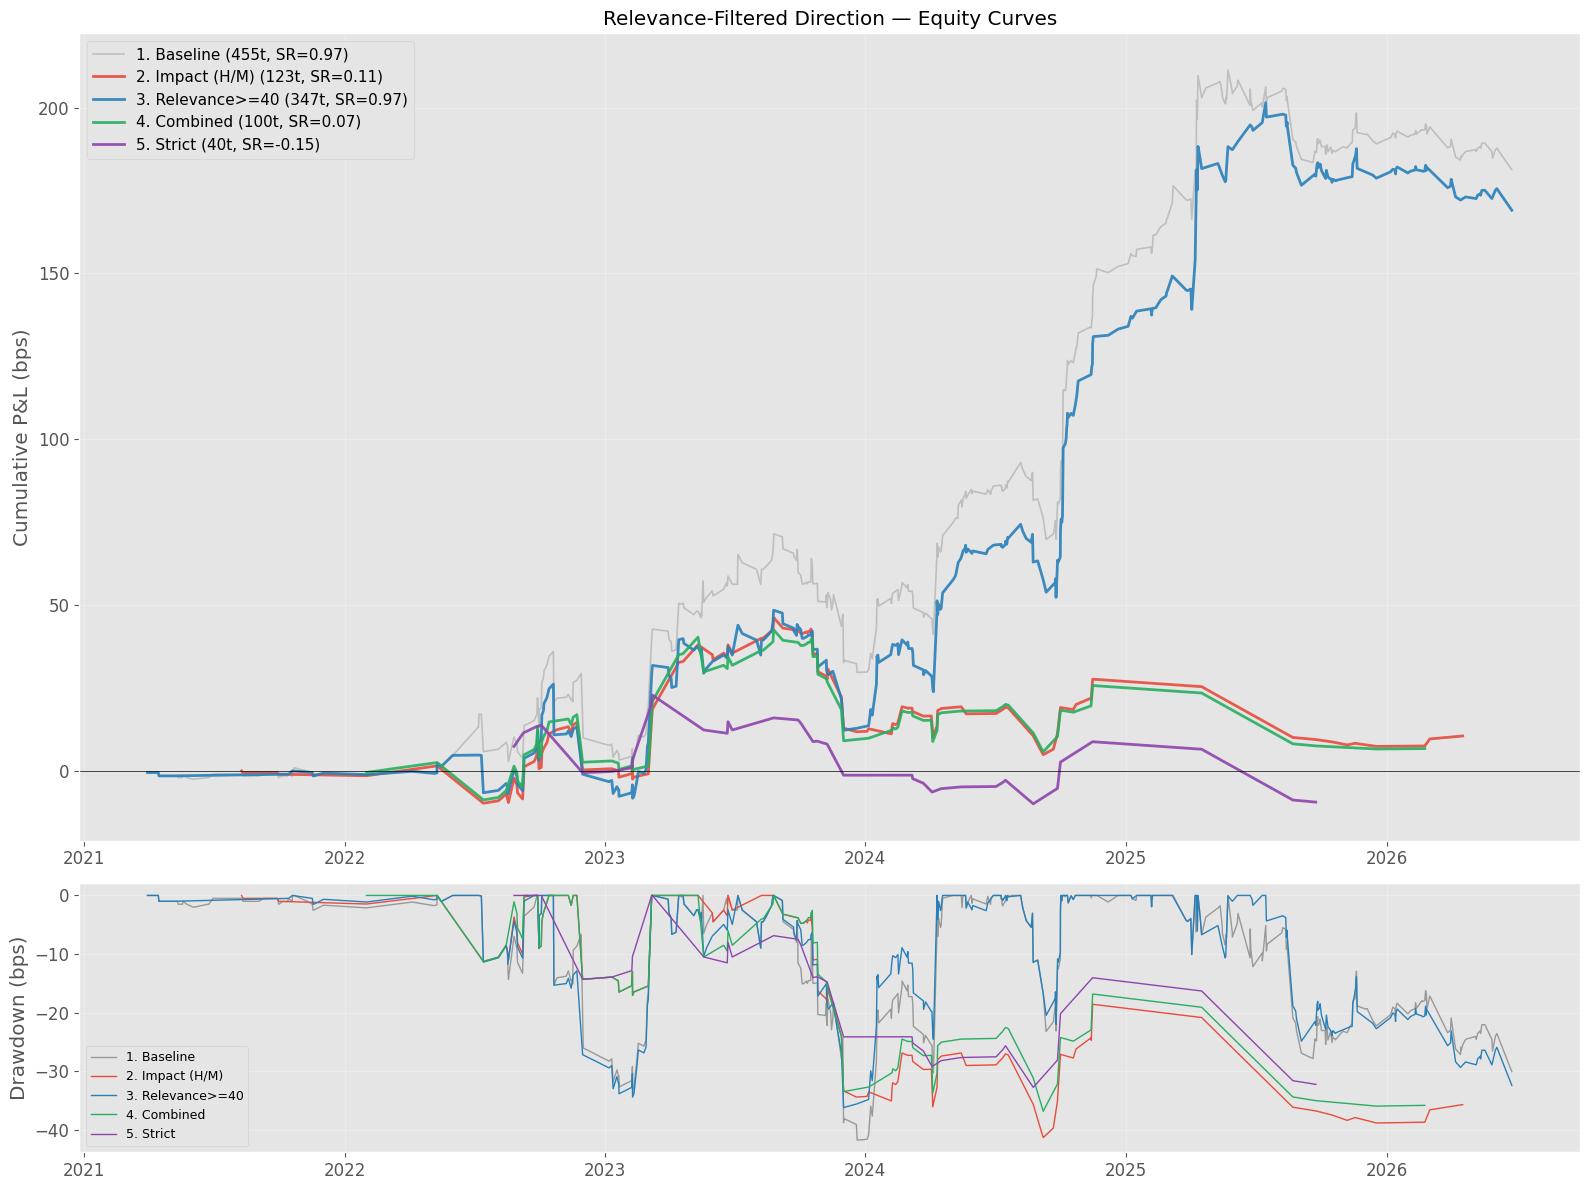

In [6]:
def _sharpe(cl):
    n = len(cl)
    yrs = max((cl["opened_at"].max() - cl["opened_at"].min()).days / 365.25, 0.5)
    std = cl["pnl_bps"].std()
    avg = cl["pnl_bps"].mean()
    return (avg / std * np.sqrt(n / yrs)) if std > 0 else 0

COLORS = {
    "1. Baseline": "#999999",
    "2. Impact (H/M)": "#e74c3c",
    "3. Relevance>=40": "#2980b9",
    "4. Combined": "#27ae60",
    "5. Strict": "#8e44ad",
}

fig, axes = plt.subplots(2, 1, figsize=(16, 12), gridspec_kw={"height_ratios": [3, 1]})
ax = axes[0]
for name in all_closed:
    cl = all_closed[name]
    ax.plot(cl["opened_at"].values, cl["cum_bps"].values,
            lw=2 if "Baseline" not in name else 1.2,
            color=COLORS.get(name, "gray"),
            alpha=0.5 if "Baseline" in name else 0.9,
            label=f"{name} ({len(cl)}t, SR={_sharpe(cl):.2f})")
ax.axhline(0, color="k", lw=0.5)
ax.set_ylabel("Cumulative P&L (bps)")
ax.set_title("Relevance-Filtered Direction — Equity Curves")
ax.legend(loc="upper left", fontsize=11)
ax.grid(True, alpha=0.3)

ax2 = axes[1]
for name in all_closed:
    cl = all_closed[name]
    dd = cl["cum_bps"] - cl["cum_bps"].cummax()
    ax2.plot(cl["opened_at"].values, dd.values, lw=1,
             color=COLORS.get(name, "gray"), label=name)
ax2.set_ylabel("Drawdown (bps)")
ax2.legend(loc="lower left", fontsize=9)
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Summary Comparison

In [7]:
rows = []
for name in all_closed:
    cl = all_closed[name]
    hawk = cl["direction"] == 1
    rows.append({
        "Variant": name, "Trades": len(cl),
        "Hawk / Dove": f"{hawk.sum()} / {(~hawk).sum()}",
        "Cum bps": cl["pnl_bps"].sum(),
        "Avg bps": cl["pnl_bps"].mean(),
        "Med bps": cl["pnl_bps"].median(),
        "Std bps": cl["pnl_bps"].std(),
        "Hit Rate": cl["profitable"].mean(),
        "Sharpe": _sharpe(cl),
        "Max DD": (cl["cum_bps"] - cl["cum_bps"].cummax()).min(),
        "Hawk bps": cl.loc[hawk, "pnl_bps"].sum(),
        "Dove bps": cl.loc[~hawk, "pnl_bps"].sum(),
    })

summary = pd.DataFrame(rows)
display(summary.style.format({
    "Cum bps": "{:+.1f}", "Avg bps": "{:+.3f}", "Med bps": "{:+.3f}",
    "Std bps": "{:.2f}", "Hit Rate": "{:.1%}", "Sharpe": "{:.2f}",
    "Max DD": "{:.1f}", "Hawk bps": "{:+.1f}", "Dove bps": "{:+.1f}",
}).background_gradient(subset=["Sharpe"], cmap="RdYlGn"))

,Variant,Trades,Hawk / Dove,Cum bps,Avg bps,Med bps,Std bps,Hit Rate,Sharpe,Max DD,Hawk bps,Dove bps
0,1. Baseline,455,380 / 75,+181.3,+0.398,+0.147,3.83,57.4%,0.97,-41.8,+197.3,-16.0
1,2. Impact (H/M),123,108 / 15,+10.5,+0.086,+0.115,3.99,56.9%,0.11,-41.4,+9.2,+1.4
2,3. Relevance>=40,347,319 / 28,+169.1,+0.487,+0.365,4.10,59.4%,0.97,-36.2,+178.3,-9.2
3,4. Combined,100,96 / 4,+6.7,+0.067,+0.372,4.50,60.0%,0.07,-36.8,+6.2,+0.5
4,5. Strict,40,40 / 0,-9.4,-0.235,+0.118,5.51,57.5%,-0.15,-32.8,-9.4,+0.0


## 7. Calendar-Year Breakdown

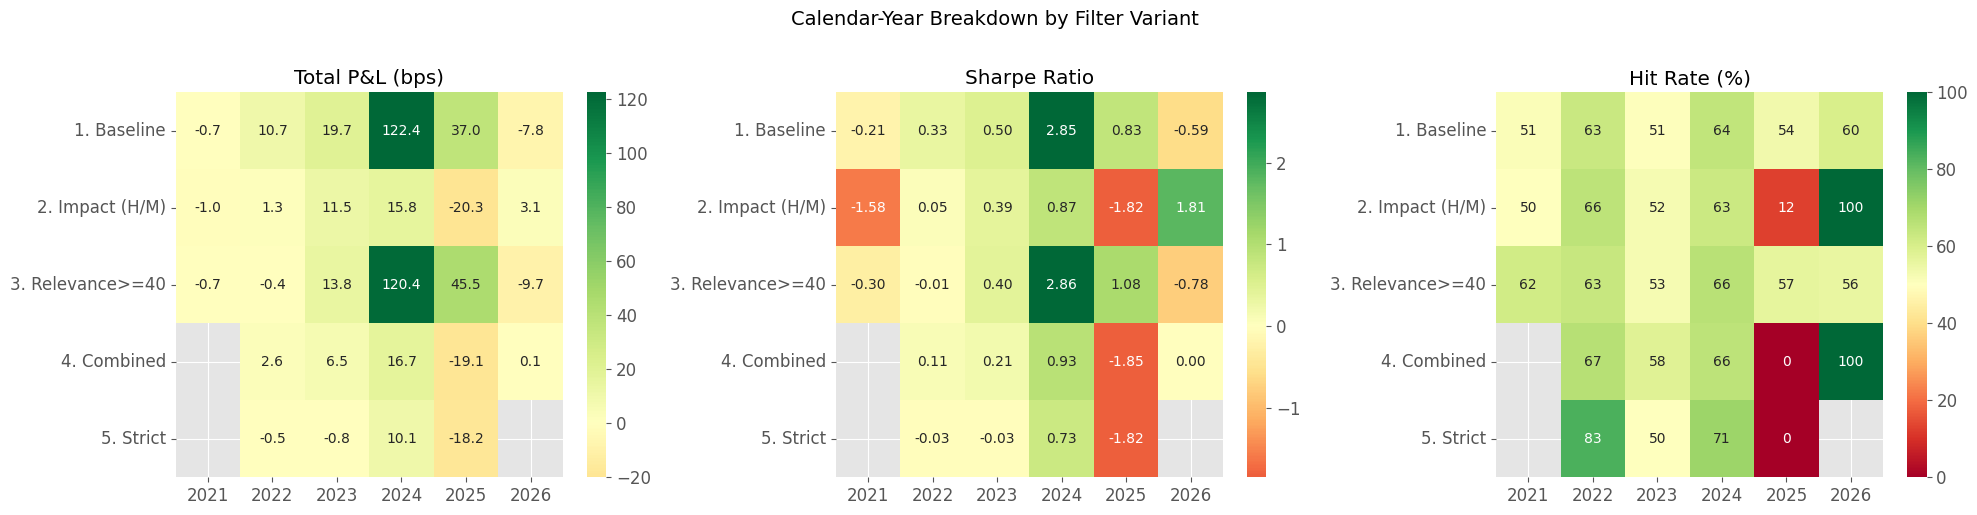

In [8]:
all_years = sorted(set(y for cl in all_closed.values() for y in cl["year"].unique()))
yr_bps = pd.DataFrame(index=list(all_closed.keys()), columns=all_years, dtype=float)
yr_sr = yr_bps.copy()
yr_hit = yr_bps.copy()

for name in all_closed:
    cl = all_closed[name]
    for yr, grp in cl.groupby("year"):
        n = len(grp); avg = grp["pnl_bps"].mean(); std = grp["pnl_bps"].std()
        yr_bps.loc[name, yr] = grp["pnl_bps"].sum()
        yr_sr.loc[name, yr] = (avg / std * np.sqrt(n)) if std > 0 else 0
        yr_hit.loc[name, yr] = grp["profitable"].mean()

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
sns.heatmap(yr_bps.astype(float), annot=True, fmt=".1f", cmap="RdYlGn", center=0, ax=axes[0])
axes[0].set_title("Total P&L (bps)")
sns.heatmap(yr_sr.astype(float), annot=True, fmt=".2f", cmap="RdYlGn", center=0, ax=axes[1])
axes[1].set_title("Sharpe Ratio")
sns.heatmap(yr_hit.astype(float)*100, annot=True, fmt=".0f", cmap="RdYlGn", center=50, ax=axes[2])
axes[2].set_title("Hit Rate (%)")
for ax in axes: ax.set_ylabel("")
plt.suptitle("Calendar-Year Breakdown by Filter Variant", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

## 8. Hawk vs Dove Split

,Variant,Direction,Trades,Cum bps,Avg bps,Hit Rate
0,1. Baseline,hawk,380,+197.3,+0.519,58.4%
1,1. Baseline,dove,75,-16.0,-0.213,52.0%
2,2. Impact (H/M),hawk,108,+9.2,+0.085,57.4%
3,2. Impact (H/M),dove,15,+1.4,+0.091,53.3%
4,3. Relevance>=40,hawk,319,+178.3,+0.559,59.6%
5,3. Relevance>=40,dove,28,-9.2,-0.330,57.1%
6,4. Combined,hawk,96,+6.2,+0.065,60.4%
7,4. Combined,dove,4,+0.5,+0.121,50.0%
8,5. Strict,hawk,40,-9.4,-0.235,57.5%


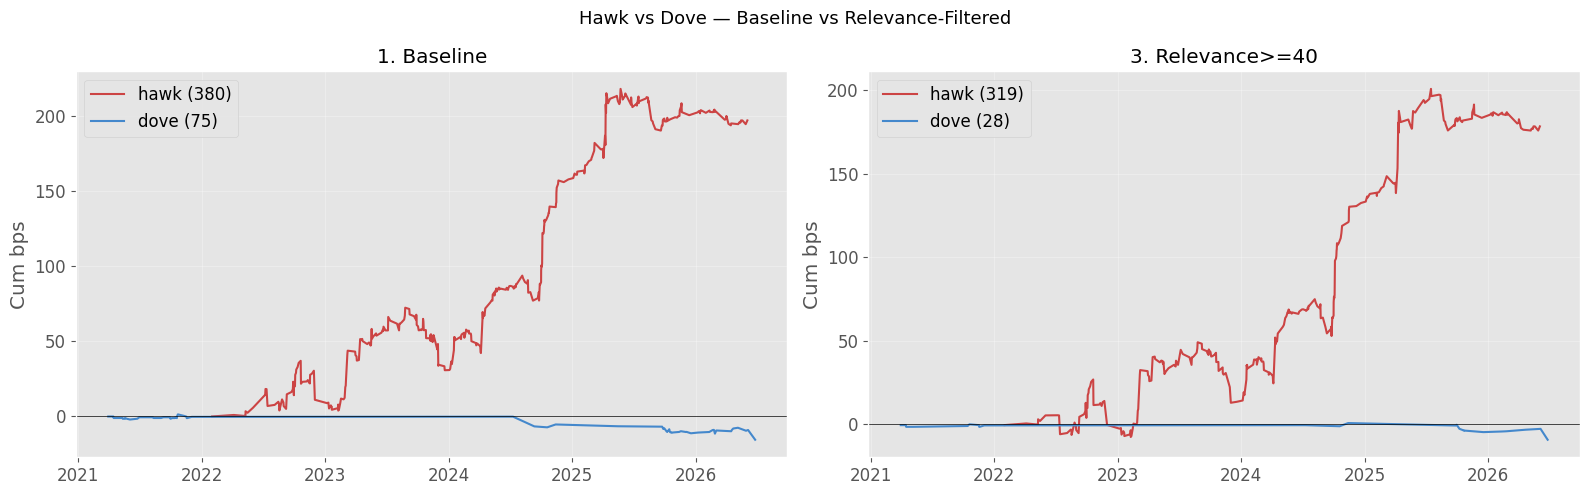

In [9]:
dir_rows = []
for name in all_closed:
    cl = all_closed[name]
    for d_label in ["hawk", "dove"]:
        sub = cl[cl["direction_label"] == d_label]
        if len(sub) == 0: continue
        dir_rows.append({
            "Variant": name, "Direction": d_label,
            "Trades": len(sub), "Cum bps": sub["pnl_bps"].sum(),
            "Avg bps": sub["pnl_bps"].mean(), "Hit Rate": sub["profitable"].mean(),
        })
dir_df = pd.DataFrame(dir_rows)
display(dir_df.style.format({
    "Cum bps": "{:+.1f}", "Avg bps": "{:+.3f}", "Hit Rate": "{:.1%}",
}))

# Hawk/dove curves for best variant
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for idx, name in enumerate(["1. Baseline", "3. Relevance>=40"]):
    if name not in all_closed: continue
    ax = axes[idx]
    cl = all_closed[name]
    for d, color in [("hawk", "#cc4444"), ("dove", "#4488cc")]:
        mask = cl["direction_label"] == d
        sub = cl[mask].sort_values("opened_at")
        if len(sub) == 0: continue
        ax.plot(sub["opened_at"].values, sub["pnl_bps"].cumsum().values,
                lw=1.5, color=color, label=f"{d} ({mask.sum()})")
    ax.axhline(0, color="k", lw=0.5)
    ax.set_ylabel("Cum bps"); ax.set_title(name)
    ax.legend(); ax.grid(True, alpha=0.3)
plt.suptitle("Hawk vs Dove — Baseline vs Relevance-Filtered", fontsize=13)
plt.tight_layout(); plt.show()

## 9. Annual P&L Comparison

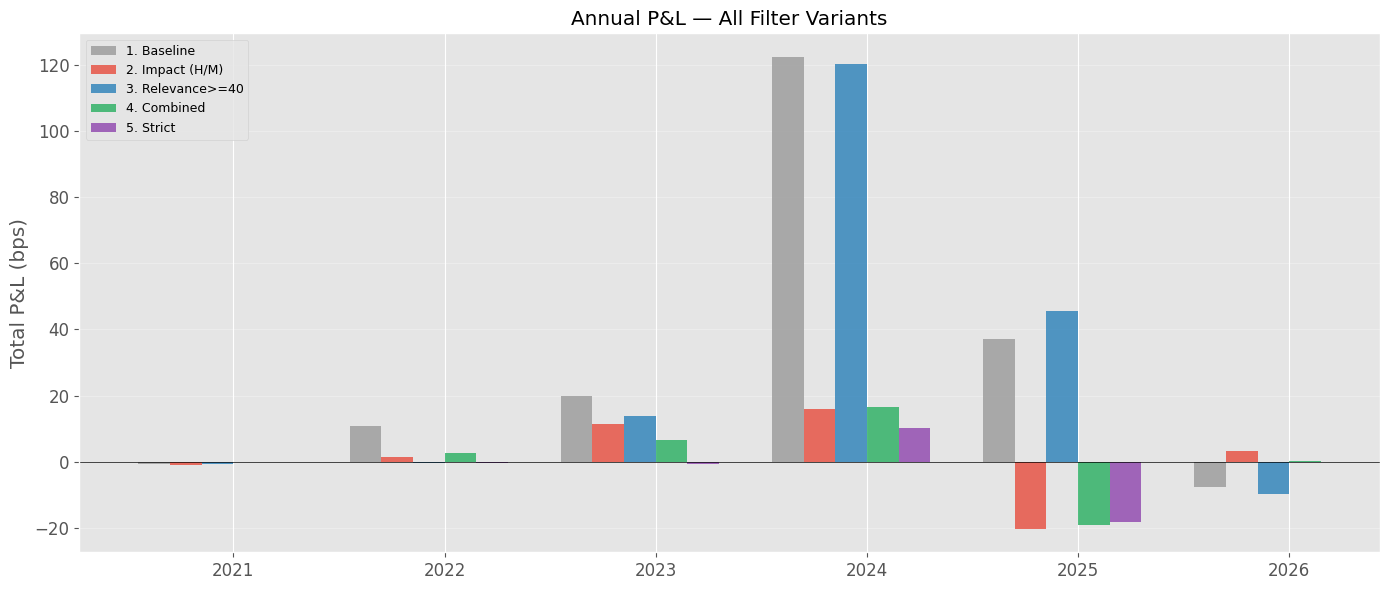

Positive years per variant:
  1. Baseline               4/6
  2. Impact (H/M)           4/6
  3. Relevance>=40          3/6
  4. Combined               4/5
  5. Strict                 1/4


In [10]:
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(all_years))
w = 0.15
names = list(all_closed.keys())
for i, name in enumerate(names):
    vals = [yr_bps.loc[name, yr] if yr in yr_bps.columns else 0 for yr in all_years]
    ax.bar(x + (i - len(names)/2) * w, vals, w,
           label=name, color=COLORS.get(name, "gray"), alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(all_years)
ax.axhline(0, color="k", lw=0.5)
ax.set_ylabel("Total P&L (bps)"); ax.set_title("Annual P&L — All Filter Variants")
ax.legend(fontsize=9, loc="upper left"); ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

print("Positive years per variant:")
for name in all_closed:
    vals = [yr_bps.loc[name, yr] for yr in all_years if not pd.isna(yr_bps.loc[name, yr])]
    pos = sum(1 for v in vals if v > 0)
    print(f"  {name:25s} {pos}/{len(vals)}")

## 10. Speaker Attribution — Relevance-Filtered

,trades,total_bps,avg_bps,hit_rate
speaker,,,,
Barkin,50,+30.7,+0.613,60.0%
Musalem,20,+27.3,+1.365,70.0%
Bowman,27,+23.9,+0.884,48.1%
Logan,14,+19.6,+1.398,57.1%
Collins,5,+16.1,+3.216,80.0%
Bostic,37,+15.7,+0.425,70.3%
Waller,30,+15.0,+0.499,73.3%
Kashkari,11,+13.6,+1.233,72.7%
Powell,33,+9.1,+0.277,60.6%


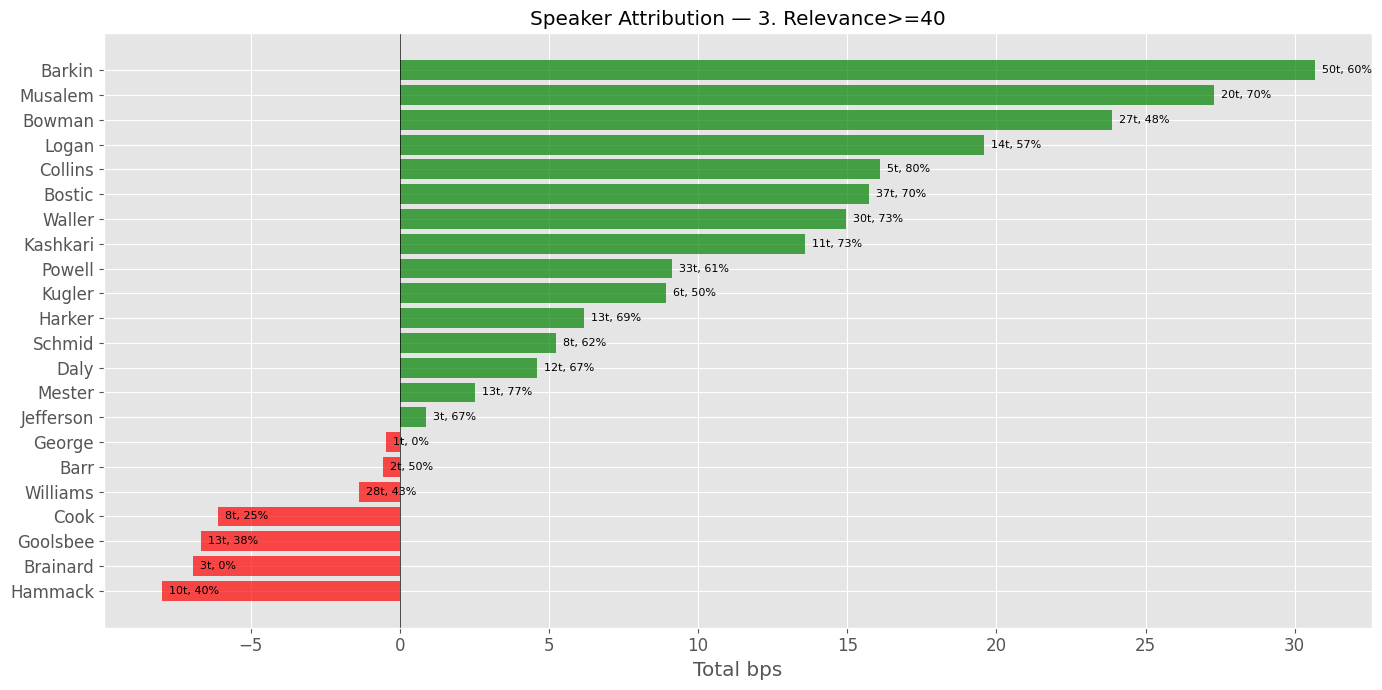

In [11]:
best = "3. Relevance>=40"
if best in all_closed:
    cl = all_closed[best]
    sp = cl.groupby("speaker").agg(
        trades=("pnl_bps", "count"), total_bps=("pnl_bps", "sum"),
        avg_bps=("pnl_bps", "mean"), hit_rate=("profitable", "mean"),
    ).sort_values("total_bps", ascending=False)
    display(sp.style.format({
        "total_bps": "{:+.1f}", "avg_bps": "{:+.3f}", "hit_rate": "{:.1%}"}))

    fig, ax = plt.subplots(figsize=(14, 7))
    sp_sorted = sp.sort_values("total_bps")
    colors = ["green" if x > 0 else "red" for x in sp_sorted["total_bps"]]
    ax.barh(sp_sorted.index, sp_sorted["total_bps"], color=colors, alpha=0.7)
    ax.axvline(0, color="k", lw=0.5); ax.set_xlabel("Total bps")
    ax.set_title(f"Speaker Attribution — {best}")
    for i, (speaker, row) in enumerate(sp_sorted.iterrows()):
        ax.text(row["total_bps"], i,
                f"  {row['trades']:.0f}t, {row['hit_rate']:.0%}",
                va="center", fontsize=8)
    plt.tight_layout(); plt.show()
else:
    print(f"{best} not found in results")